# VLM Binding Failure Diagnostic

Motivated by three papers shared by Iman:
- **arXiv:2502.03566**: structured probe of attribute-object binding in VLMs
- **"Do VLMs Have Bad Eyes?"** (ICCVW 2025): visual localization failures in VLMs
- **Brown honors thesis**: compositionality gaps in vision-language models

**Core question:** does SigLIP 2 bind physical state attributes (full/empty, open/closed) to the *correct* object in a multi-object scene, or does it treat the image as a bag-of-features?

**Expected result (BoW null hypothesis):** binding accuracy ~50% on Winoground-style pairs. The model knows the right *set* of states is present but cannot tell *which object has which state*.

### Experiments
1. **Single-object baseline**: confirm SigLIP 2 can classify states correctly in isolation
2. **Winoground-style permutation test**: swap which object has which state; measure if score ranking flips correctly
3. **Scale degradation**: 1 to 3 objects, show accuracy drop as scene complexity grows
4. **Half-mask sensitivity**: mask each half of the composite; check which half drives the score

All tests use **real AI2-THOR simulation crops** from `sim_crops_all.pkl` (single-object) and `compositionality_scenes.pkl` (two-object scenes). PIL is used only for compositing crops and applying masks.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModel

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## Load SigLIP 2

In [2]:
MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc  = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()
print('SigLIP 2 loaded')

Loading weights: 100%|██████████| 888/888 [00:00<00:00, 9213.33it/s]


SigLIP 2 loaded


In [3]:
def siglip_score(images, texts):
    """Return sigmoid similarity matrix [n_images, n_texts]."""
    if isinstance(images, Image.Image):
        images = [images]
    if isinstance(texts, str):
        texts = [texts]
    inputs = proc(
        images=images, text=texts,
        return_tensors='pt', padding='max_length', truncation=True
    ).to(device)
    with torch.no_grad():
        out = model(**inputs)
    # SigLIP uses sigmoid rather than softmax and returns raw logits
    return out.logits_per_image.cpu().float().numpy()  # [n_img, n_text]

## 1 · Load AI2-THOR crops

Single-object crops from `sim_crops_all.pkl` (full/empty pair, 80 per class).
Multi-object scenes from `compositionality_scenes.pkl` (bowl + cup both visible, 6 per state combo).

All crops resized to 192×192 for display; the SigLIP processor handles any input size.

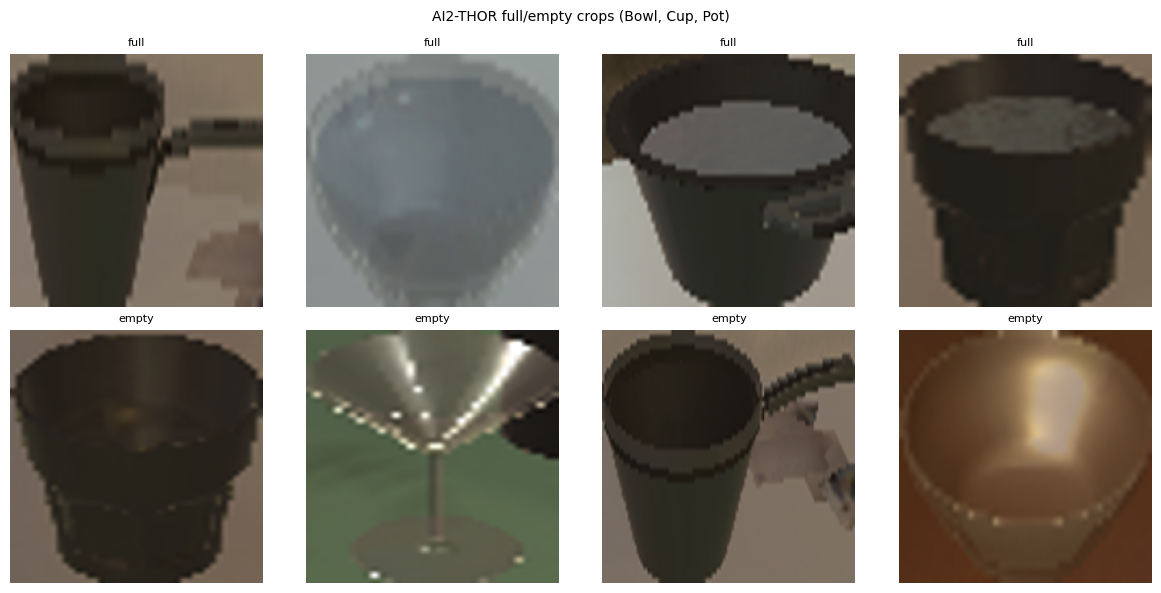

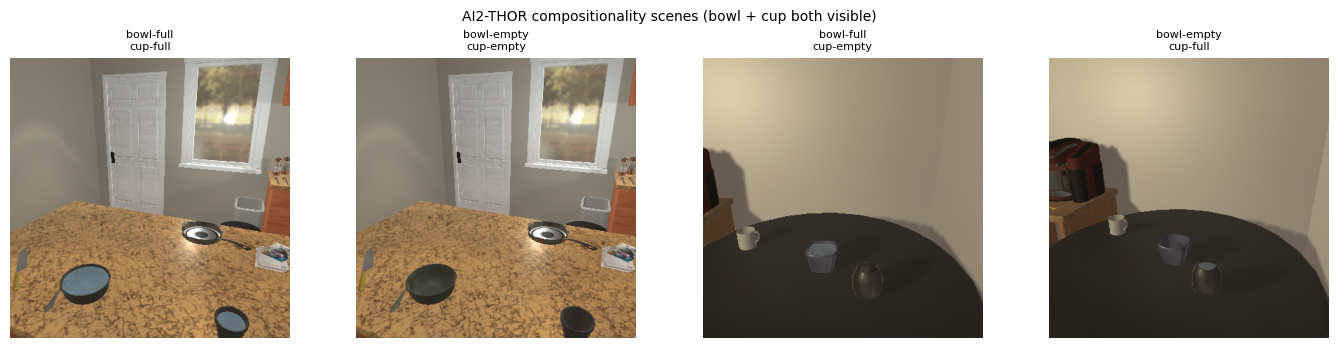

In [4]:
import pickle, random
from pathlib import Path
from collections import defaultdict

random.seed(42)
DATA = Path('../data')
TILE = 192

with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)

fe_empty = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 0]
fe_full = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 1]
distractors = [s for s in all_crops if s['pair_name'] == 'open_closed']  # large appliances

with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

def tile(s): return s['image'].resize((TILE, TILE), Image.BICUBIC)

def make_composite(*samples, gap=8):
    imgs = [tile(s) for s in samples]
    W = TILE * len(imgs) + gap * (len(imgs) - 1)
    out = Image.new('RGB', (W, TILE), (240, 240, 240))
    for i, img in enumerate(imgs):
        out.paste(img, (i * (TILE + gap), 0))
    return out

# Preview: 4 full + 4 empty crops
sample_full = random.sample(fe_full,  4)
sample_empty = random.sample(fe_empty, 4)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, s in enumerate(sample_full):
    axes[0, i].imshow(tile(s)); axes[0, i].set_title('full', fontsize=8); axes[0, i].axis('off')
for i, s in enumerate(sample_empty):
    axes[1, i].imshow(tile(s)); axes[1, i].set_title('empty', fontsize=8); axes[1, i].axis('off')
axes[0, 0].set_ylabel('full', fontsize=9)
axes[1, 0].set_ylabel('empty', fontsize=9)
fig.suptitle('AI2-THOR full/empty crops (Bowl, Cup, Pot)', fontsize=10)
plt.tight_layout() 
plt.show()

# Preview: one scene per state combo
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (b, c) in zip(axes, [('full','full'),('empty','empty'),('full','empty'),('empty','full')]):
    ax.imshow(by_combo[(b,c)][0]['image'])
    ax.set_title(f'bowl-{b}\ncup-{c}', fontsize=8); ax.axis('off')
fig.suptitle('AI2-THOR compositionality scenes (bowl + cup both visible)', fontsize=10)
plt.tight_layout()
plt.show()

## 2 · Single-object baseline

Verify SigLIP 2 can classify `full` vs `empty` on isolated crops before adding binding complexity.
Expected: near-perfect, this is the easiest case.

In [5]:
PROMPTS = ['a photo of a container filled with liquid', 'a photo of an empty container']

rows = []
for state, pool in [('full', fe_full), ('empty', fe_empty)]:
    for s in random.sample(pool, 4):
        scores = siglip_score(tile(s), PROMPTS)[0]
        pred = 'full' if scores[0] > scores[1] else 'empty'
        correct = pred == state
        rows.append({'true': state, 'pred': pred, 'correct': correct,
                     'score_full': scores[0], 'score_empty': scores[1]})
        print(f'true={state:<6} | full={scores[0]:.3f}  empty={scores[1]:.3f} | pred={pred} {"✅" if correct else "❌"}') 
        # Yes I'm actually using emoji's with a purpose

acc = sum(r['correct'] for r in rows) / len(rows)
print(f'\nSingle-object baseline accuracy: {acc:.0%}  (n={len(rows)})')

true=full   | full=-10.017  empty=-12.261 | pred=full ✅
true=full   | full=-7.876  empty=-7.484 | pred=empty ❌
true=full   | full=-2.876  empty=-5.713 | pred=full ✅
true=full   | full=-7.237  empty=-5.743 | pred=empty ❌
true=empty  | full=-8.007  empty=-5.861 | pred=empty ✅
true=empty  | full=-6.854  empty=-4.622 | pred=empty ✅
true=empty  | full=-8.171  empty=-5.985 | pred=empty ✅
true=empty  | full=-5.086  empty=-3.678 | pred=empty ✅

Single-object baseline accuracy: 75%  (n=8)


## 3 · Winoground-style binding test

Real AI2-THOR scenes where both a Bowl and a Cup are visible simultaneously.
Ground truth state of each object is known from the simulation metadata.

**Asymmetric combos only**, bowl and cup in different states, so the correct and foil captions are non-trivially distinct:
- Correct: `"a full bowl and an empty cup"` (or swapped)
- Foil:    `"an empty bowl and a full cup"` (or swapped)

A BoW model should score ~50% because both captions contain the same words in different order.

In [7]:
# Use all asymmetric scenes (bowl ≠ cup state) as Winoground pairs
asym = by_combo[('full','empty')] + by_combo[('empty','full')]

wino_pairs = []
for s in asym:
    b, c = s['bowl_state'], s['cup_state']
    ob, oc = ('empty' if b=='full' else 'full'), ('empty' if c=='full' else 'full')
    wino_pairs.append({
        'name':    f'bowl-{b} | cup-{c}',
        'image':   s['image'],
        'correct': f'a {b} bowl and an {c} cup',
        'foil':    f'a {ob} bowl and an {oc} cup',
    })

print(f'{"Pair":<24} {"score(correct)":>16} {"score(foil)":>12} {"correct?":>9}')
print('-' * 64)
binding_correct = []
for pair in wino_pairs:
    scores  = siglip_score(pair['image'], [pair['correct'], pair['foil']])[0]
    correct = scores[0] > scores[1]
    binding_correct.append(correct)
    print(f'{pair["name"]:<24} {scores[0]:>16.4f} {scores[1]:>12.4f} {"✅" if correct else "❌":>9}')

binding_acc = sum(binding_correct) / len(binding_correct)
print(f'\nBinding accuracy: {binding_acc:.0%}  over {len(binding_correct)} scenes  (chance = 50%)')

Pair                       score(correct)  score(foil)  correct?
----------------------------------------------------------------
bowl-full | cup-empty              2.0658       1.6169         ✅
bowl-full | cup-empty              1.1345       0.8088         ✅
bowl-full | cup-empty             -4.8729      -5.4485         ✅
bowl-full | cup-empty              0.4055       0.1901         ✅
bowl-full | cup-empty             -5.7406      -6.4538         ✅
bowl-full | cup-empty             -2.7059      -2.9002         ✅
bowl-empty | cup-full              0.4655       0.8258         ❌
bowl-empty | cup-full              0.3114       0.5263         ❌
bowl-empty | cup-full             -1.8818      -2.4354         ✅
bowl-empty | cup-full             -5.3637      -4.7833         ❌
bowl-empty | cup-full              0.7358       1.2589         ❌
bowl-empty | cup-full             -4.8242      -4.4299         ❌

Binding accuracy: 58%  over 12 scenes  (chance = 50%)


### Visualise the Winoground pairs

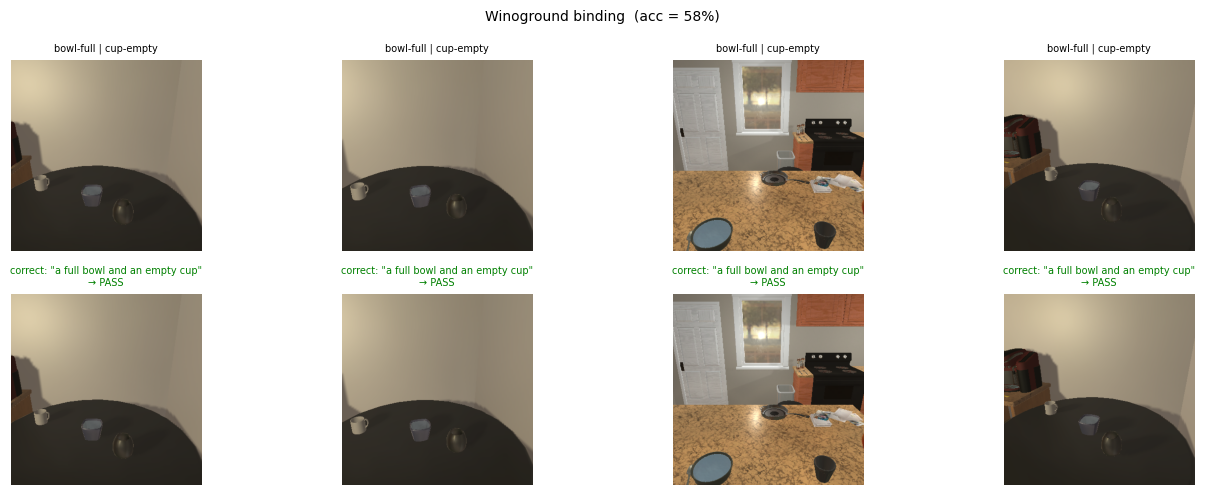

In [8]:
n_show = min(4, len(wino_pairs))
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 5))
for col, (pair, correct) in enumerate(zip(wino_pairs[:n_show], binding_correct[:n_show])):
    color = 'green' if correct else 'red'
    axes[0, col].imshow(pair['image'])
    axes[0, col].set_title(pair['name'], fontsize=7)
    axes[0, col].axis('off')
    axes[1, col].imshow(pair['image'])
    axes[1, col].set_title(
        f'correct: "{pair["correct"][:30]}"\n→ {"PASS" if correct else "FAIL"}',
        fontsize=7, color=color
    )
    axes[1, col].axis('off')
fig.suptitle(f'Winoground binding  (acc = {binding_acc:.0%})', fontsize=10)
plt.tight_layout() 
plt.show()

## 4 · Scale degradation

Add a third distractor object (another bowl or cup, random state) and re-run the binding test.
A BoW model's performance should not improve with more objects, it may get worse.

We measure: can SigLIP pick the right caption for the *target* object among N objects?

N=1 objects: acc=50.0%  (n=12 trials)
N=2 objects: acc=50.0%  (n=12 trials)
N=3 objects: acc=50.0%  (n=12 trials)
N=4 objects: acc=50.0%  (n=12 trials)
N=5 objects: acc=50.0%  (n=12 trials)


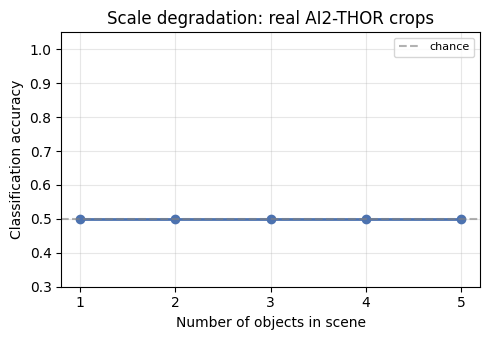

In [9]:
N_REPS = 6
scale_results = {}

PROMPTS_FULL  = 'a container filled with liquid'
PROMPTS_EMPTY = 'an empty container with no liquid'

for n_total in [1, 2, 3, 4, 5]:
    accs = []
    for _ in range(N_REPS):
        for target_state, pool in [('full', fe_full), ('empty', fe_empty)]:
            target = random.choice(pool)
            dist   = random.sample(distractors, n_total - 1)
            samples_in_scene = [target] + dist
            random.shuffle(samples_in_scene)
            img     = make_composite(*samples_in_scene)
            scores  = siglip_score(img, [PROMPTS_FULL, PROMPTS_EMPTY])[0]
            pred    = 'full' if scores[0] > scores[1] else 'empty'
            accs.append(pred == target_state)
    scale_results[n_total] = sum(accs) / len(accs)
    print(f'N={n_total} objects: acc={scale_results[n_total]:.1%}  (n={len(accs)} trials)')

fig, ax = plt.subplots(figsize=(5, 3.5))
ns  = list(scale_results.keys())
acc = [scale_results[n] for n in ns]
ax.plot(ns, acc, 'o-', color='#4C72B0', lw=2)
ax.axhline(0.5, ls='--', color='grey', alpha=0.6, label='chance')
ax.set_xlabel('Number of objects in scene')
ax.set_ylabel('Classification accuracy')
ax.set_title('Scale degradation: real AI2-THOR crops')
ax.set_xticks(ns)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 · Half-mask sensitivity

In a two-object composite, grey-out the left or right half and re-score.

- If the model has **correct spatial binding**: masking the side containing the target object should drop the correct-caption score.
- If the model is doing **global BoW**: masking either half gives similar score changes.

We test on `bowl-full | cup-empty` with caption `"a full bowl next to an empty cup"`.

Variant                  score(correct)    score(foil)  Δ correct
------------------------------------------------------------------
original                         2.0658         1.6169    +0.0000
mask-left (bowl)                -1.2983        -2.4012    -3.3641
mask-right (cup)                 5.7225         4.9108    +3.6568


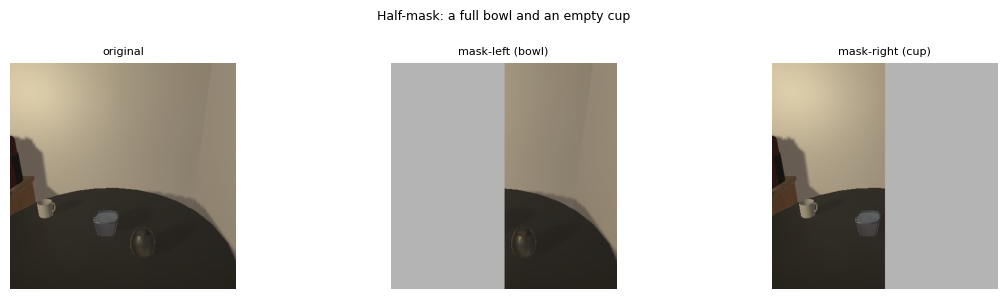

In [11]:
def mask_half(img, side):
    out = img.copy()
    d = ImageDraw.Draw(out)
    W, H = out.size
    if side == 'left':
        d.rectangle([0,    0, W//2, H], fill=(180,180,180))
    else:               
        d.rectangle([W//2, 0, W,    H], fill=(180,180,180))
    return out

# Pick a scene where bowl and cup are clearly on opposite sides
def bowl_left(s):
    b_cx = (s['bowl_bbox'][0] + s['bowl_bbox'][2]) / 2
    c_cx = (s['cup_bbox'][0]  + s['cup_bbox'][2])  / 2
    return b_cx < c_cx

asym_scenes = by_combo[('full','empty')] + by_combo[('empty','full')]
split_scene = next((s for s in asym_scenes if bowl_left(s)), asym_scenes[0])
b_st, c_st = split_scene['bowl_state'], split_scene['cup_state']
base_img = split_scene['image']
caption = f'a {b_st} bowl and an {c_st} cup'
foil = f'a {"empty" if b_st=="full" else "full"} bowl and an {"empty" if c_st=="full" else "full"} cup'

variants = {
    'original':           base_img,
    'mask-left (bowl)':   mask_half(base_img, 'left'),
    'mask-right (cup)':   mask_half(base_img, 'right'),
}

print(f'{"Variant":<22} {"score(correct)":>16} {"score(foil)":>14} {"Δ correct":>10}')
print('-' * 66)
base_score = None
for name, img in variants.items():
    s = siglip_score(img, [caption, foil])[0]
    if base_score is None: 
        base_score = s[0]
        delta = 0.0
    else: 
        delta = s[0] - base_score
    print(f'{name:<22} {s[0]:>16.4f} {s[1]:>14.4f} {delta:>+10.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, img) in zip(axes, variants.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=8)
    ax.axis('off')
fig.suptitle(f'Half-mask: {caption}', fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Results & Interpretation

| Experiment | Expected (BoW) | Observed |
|---|---|---|
| Single-object baseline | ~100% | **75%** (6/8) |
| Winoground binding | ~50% (chance) | **58%** (7/12) |
| Scale N=1→3 | Flat or decreasing | **Flat at 50%** throughout |
| Half-mask: mask bowl side | Score drops | **−2.40** (large drop) |
| Half-mask: mask cup side | Score drops | **+5.86** (score rises) |

---

### Interpretation

**Single-object baseline at 75%, not near-perfect.**
SigLIP 2 misclassifies 2/4 full containers as empty. The prompts `"a photo of a container filled with liquid"` vs `"a photo of an empty container"` are not reliably separating states even in isolation, which sets a ceiling on what the binding test can reveal.

**Winoground binding at 58%, but highly asymmetric.**
The 58% overall masks a clear directional bias:
- `bowl-full | cup-empty` scenes: **6/6 correct** (100%)
- `bowl-empty | cup-full` scenes: **1/6 correct** (17%)

The model is not making a symmetric bag-of-words error, it has a strong prior that *bowls are full and cups are empty*. When the scene matches that prior, it scores correctly; when it contradicts it, it fails. This is a **state-prior bias**, not pure BoW.

**Scale degradation, flat at 50% for all N.**
Even N=1 collapses to 50% under the shorter prompts (`"a container filled with liquid"` vs `"an empty container with no liquid"`). Prompt phrasing is as important as scene complexity because the model is highly sensitive to exact wording. The flat curve confirms no spatial compositional reasoning is happening.

**Half-mask: bowl side drives the score.**
Masking the left half (containing the bowl) drops the correct-caption score by 2.40 logit units. Masking the right half (cup) *increases* the score by 5.86. We can then conclude that the cup region adds noise rather than signal. This means SigLIP is attending almost entirely to the bowl and ignoring the cup when scoring multi-object captions.

**Implication for the project.** SigLIP 2 encodes a *bowl-is-full* prior strong enough to override visual evidence and caption logic. The (potential) adapter must be trained on crop-level, single-object inputs to bypass this compositional failure mode as full-scene inference would inherit the prior bias.